# 09. Putting It All Together — Final Comparison — PyTorch

We combine **He/Kaiming init + BatchNorm + Dropout + Adam + gradient clipping + early stopping** into one tuned model and compare it with the plain baseline.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `09_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Shared training loop with clipping + early stopping

In [6]:
import copy

def train_full(model, epochs=200, patience=20, clip=1.0, use_es=True):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best, best_state, wait, stop_epoch = float("inf"), None, 0, epochs
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward()
            if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        model.eval()
        with torch.no_grad():
            tr, te = model(Xtr), model(Xte); vl = loss_fn(te, yte).item()
            hist["loss"].append(loss_fn(tr, ytr).item()); hist["val_loss"].append(vl)
            hist["accuracy"].append((((tr>0.5)==(ytr>0.5)).float().mean()).item())
            hist["val_accuracy"].append((((te>0.5)==(yte>0.5)).float().mean()).item())
        if use_es:
            if vl < best - 1e-4: best, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= patience: stop_epoch = epoch + 1; break
    if use_es and best_state: model.load_state_dict(best_state)
    return hist, stop_epoch

## 5. Baseline vs tuned

In [7]:
def build_baseline():
    torch.manual_seed(42)
    return nn.Sequential(nn.Linear(N_FEATURES, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())

def build_tuned():
    torch.manual_seed(42)
    layers, prev = [], N_FEATURES
    for units in (64, 64):
        layers += [nn.Linear(prev, units, bias=False), nn.BatchNorm1d(units), nn.ReLU(), nn.Dropout(0.3)]
        prev = units
    layers += [nn.Linear(prev, 1), nn.Sigmoid()]
    model = nn.Sequential(*layers)
    for m in model:                                   # He init on the linear layers
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
    return model

hist_base,  _       = train_full(build_baseline(), use_es=False, clip=None)
hist_tuned, stopped = train_full(build_tuned(),   use_es=True,  clip=1.0)
print("Tuned model stopped at epoch", stopped)

Tuned model stopped at epoch 70


## 6. Master comparison table

In [8]:
def summarise(h, name, epochs):
    return {
        "model": name, "epochs_run": epochs,
        "final_train_acc": round(h["accuracy"][-1], 4),
        "best_test_acc":   round(max(h["val_accuracy"]), 4),
        "best_test_loss":  round(min(h["val_loss"]), 4),
        "train_test_gap":  round(h["accuracy"][-1] - h["val_accuracy"][-1], 4),
    }

pd.DataFrame([
    summarise(hist_base,  "Baseline (nb01)", len(hist_base["loss"])),
    summarise(hist_tuned, "Tuned (all techniques)", stopped),
]).set_index("model")

,epochs_run,final_train_acc,best_test_acc,best_test_loss,train_test_gap
model,,,,,
Baseline (nb01),200,0.8024,0.8618,0.3934,-0.0593
Tuned (all techniques),70,0.8045,0.8618,0.3956,-0.0492


## 7. Train vs test curves side by side

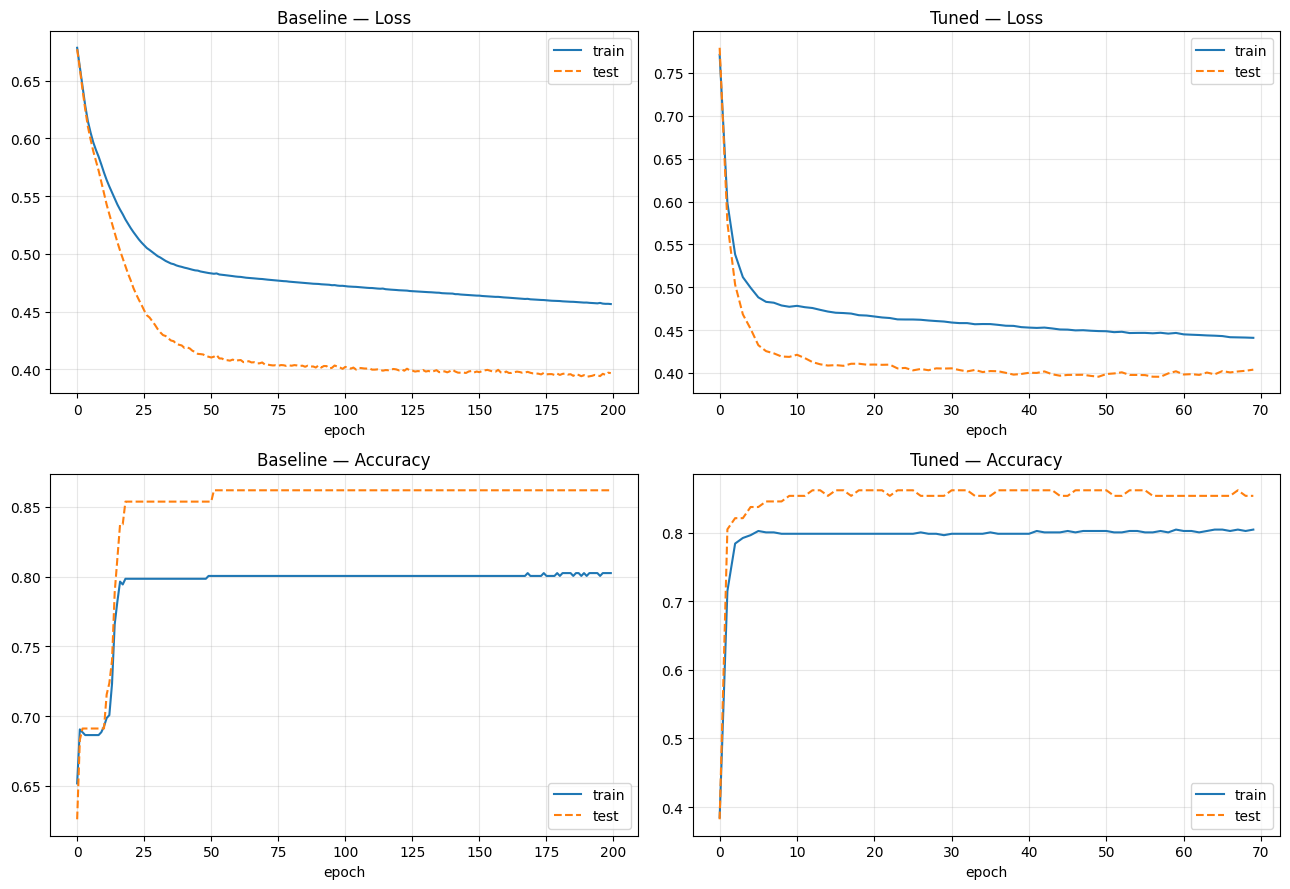

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for col, (h, name) in enumerate([(hist_base, "Baseline"), (hist_tuned, "Tuned")]):
    ax[0, col].plot(h["loss"], label="train"); ax[0, col].plot(h["val_loss"], "--", label="test")
    ax[0, col].set_title(name + " — Loss")
    ax[1, col].plot(h["accuracy"], label="train"); ax[1, col].plot(h["val_accuracy"], "--", label="test")
    ax[1, col].set_title(name + " — Accuracy")
for a in ax.ravel(): a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Final takeaways
- The **tuned** model bundles every technique from the series; watch for a smaller train–test gap and stable training.
- On this small, easy dataset the accuracy gain may be modest — the real payoff of these techniques shows on larger, noisier problems.
- **Keras vs PyTorch summary:** Keras gives you `fit` + callbacks (less code); PyTorch gives you the explicit loop (full control). Same math, same results — pick per project.

### The full series (PyTorch)
1. Baseline → 2. Optimizers → 3. Weight init → 4. Early stopping → 5. Gradient clipping → 6. BatchNorm → 7. Dropout → 8. Save/Load → 9. This comparison.

Each mirrors a `*_keras.ipynb` notebook — read them side by side to see exactly what Keras automates.